# Build OXR affinity DL model.

This notebook shows how to build a DL model to predict pIC50 in OXR receptors and will be used as a basis for transfer learning other GPCRs. 

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch

from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [ ]:
readout = 'oxr_combined'

In [4]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [24]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
df.head(5)

,Unnamed: 0,molecule_chembl_id,target_chembl_id,target_pref_name,standard_type,standard_relation,standard_value,standard_units,assay_chembl_id,assay_type,assay_description,document_chembl_id,uniprot_id,target_pref_name.1,readout,doi,year,publication_date,smiles,pActivity
0,0,CHEMBL138101,CHEMBL4792,Orexin receptor type 2,IC50,=,2000.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.698970
1,1,CHEMBL343551,CHEMBL4792,Orexin receptor type 2,IC50,=,36.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,7.443697
2,2,CHEMBL142009,CHEMBL4792,Orexin receptor type 2,IC50,=,40.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccncc1)C(C)(...,7.397940
3,3,CHEMBL343786,CHEMBL4792,Orexin receptor type 2,IC50,=,35.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccsc1)C(C)(C...,7.455932
4,4,CHEMBL139634,CHEMBL4792,Orexin receptor type 2,IC50,=,240.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccnc1)C(C)(...,6.619789


In [25]:
len(df)

7688

In [26]:
# Remove NaN pIC50s (should have been done already)
df = df[df['pActivity'].notnull() & np.isfinite(df['pActivity']) & df['smiles'].notnull()]
len(df)

7669

Is the dataset balanced?

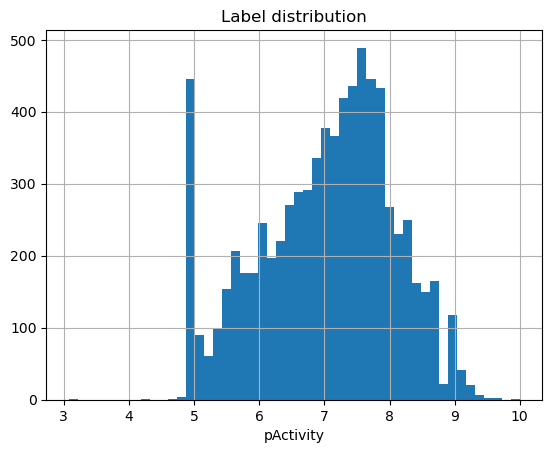

In [27]:
plt.hist(df['pActivity'], bins=50)
plt.xlabel("pActivity")
plt.title("Label distribution")
plt.grid(True)
plt.savefig("_images/sample_balance.png", dpi=300)
plt.show()

The dataset is clearly unbalanced, many compounds around pIC50 5.0. This is expected as many of the data points on Chembl records will have that value set as the 'inactive' boundary without recorting the exact value and call it '=' instead of the more correct '<'. Either way, need to sample.

In [28]:
def hybrid_balanced_sampling(
    df,
    label_col='pActivity',
    split_threshold=100,
    n_bins_low=15,
    n_bins_high=5,
    target_size=10_000,
    random_state=42
):
    np.random.seed(random_state)
    df = df.copy()

    df_low = df[df[label_col] < split_threshold]
    df_high = df[df[label_col] >= split_threshold]

    # Total bins and samples per bin
    total_bins = n_bins_low + n_bins_high
    samples_per_bin = target_size // total_bins

    # Bin low region
    bins_low = np.linspace(df_low[label_col].min(), split_threshold, n_bins_low + 1)
    df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)

    sampled_low_indices = []
    for bin_id, group in df_low.groupby('bin'):
        if len(group) == 0:
            continue
        n_sample = min(samples_per_bin, len(group))  # no oversampling here
        chosen = np.random.choice(group.index, n_sample, replace=False)
        sampled_low_indices.extend(chosen)

    # Bin high region
    bins_high = np.linspace(split_threshold, df_high[label_col].max(), n_bins_high + 1)
    df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)

    sampled_high_indices = []
    for bin_id, group in df_high.groupby('bin'):
        if len(group) == 0:
            continue
        replace = len(group) < samples_per_bin  # oversample if needed
        chosen = np.random.choice(group.index, samples_per_bin, replace=replace)
        sampled_high_indices.extend(chosen)

    all_indices = list(sampled_low_indices) + list(sampled_high_indices)
    sampled_df = df.loc[all_indices].sample(frac=1, random_state=random_state).reset_index(drop=True)
    sampled_df = sampled_df.drop(columns=['bin'], errors='ignore')

    return sampled_df


In [29]:
sampled_df = hybrid_balanced_sampling(
    df,
    label_col='pActivity',
    split_threshold=5.0,
    n_bins_low=5,
    n_bins_high=15,
    target_size=7000,
    random_state=42
)

/tmp/ipykernel_12084/1865856371.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)
/tmp/ipykernel_12084/1865856371.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)


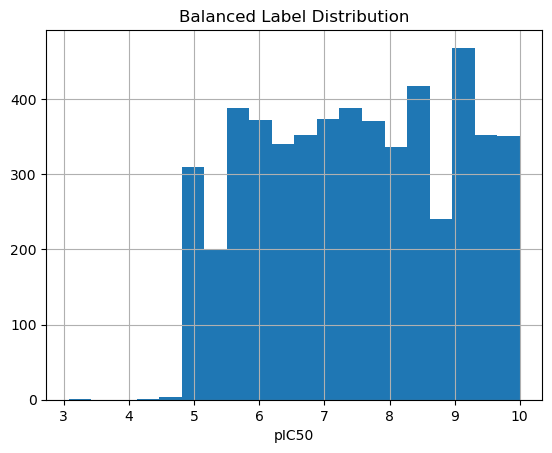

In [30]:
# Is the dataset now balanced?

plt.hist(sampled_df['pActivity'], bins=20)
plt.xlabel("pIC50")
plt.title("Balanced Label Distribution")
plt.grid(True)
plt.show()

In [31]:
s = sampled_df['pActivity']

counts, bins = np.histogram(s, bins=20)

for left, count in zip(bins[:-1], counts):
    bar = '█' * int(count / counts.max() * 50) 
    right = left + (bins[1] - bins[0])
    print(f"{left:6.2f} – {right:6.2f}: {bar} {count}")


  3.08 –   3.42:  1
  3.42 –   3.77:  0
  3.77 –   4.12:  0
  4.12 –   4.46:  1
  4.46 –   4.81:  3
  4.81 –   5.15: █████████████████████████████████ 310
  5.15 –   5.50: █████████████████████ 200
  5.50 –   5.85: █████████████████████████████████████████ 388
  5.85 –   6.19: ███████████████████████████████████████ 372
  6.19 –   6.54: ████████████████████████████████████ 340
  6.54 –   6.89: █████████████████████████████████████ 352
  6.89 –   7.23: ███████████████████████████████████████ 373
  7.23 –   7.58: █████████████████████████████████████████ 388
  7.58 –   7.92: ███████████████████████████████████████ 371
  7.92 –   8.27: ███████████████████████████████████ 336
  8.27 –   8.62: ████████████████████████████████████████████ 417
  8.62 –   8.96: █████████████████████████ 240
  8.96 –   9.31: ██████████████████████████████████████████████████ 468
  9.31 –   9.65: █████████████████████████████████████ 352
  9.65 –  10.00: █████████████████████████████████████ 350


In [32]:
smiles_list = sampled_df['smiles'].tolist()
pic50_values = sampled_df['pActivity'].tolist()

Pytorch geometric fix

In [33]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [34]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

In [35]:
def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return [int(x == s) for s in allowable_set]

## Featurisation step.

In [36]:
from rdkit.Chem import rdMolDescriptors, AllChem
from rdkit.Chem.rdchem import BondType

# --- Constants ---
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

# --- Atom features ---
def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol
    features += one_hot_encoding(atom.GetSymbol(),
                                 ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                  'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization
    features += one_hot_encoding(atom.GetHybridization(),
                                 [Chem.rdchem.HybridizationType.SP,
                                  Chem.rdchem.HybridizationType.SP2,
                                  Chem.rdchem.HybridizationType.SP3,
                                  Chem.rdchem.HybridizationType.SP3D,
                                  Chem.rdchem.HybridizationType.SP3D2,
                                  Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued local properties
    features += [
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,
        pt.GetRvdw(atomic_num) / 2.5,
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,
        pt.GetNOuterElecs(atomic_num) / 8.0,
        1.0 if atomic_num in metals else 0.0
    ]

    # --- Partial charge ---
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
        except:
            charge = 0.0
        features.append(charge)
    else:
        features.append(0.0)

    # --- Additional contextual features ---
    # In-ring + ring size
    ring_info = mol.GetRingInfo() if mol is not None else None
    in_ring = ring_info.IsAtomInRingOfSize(atom.GetIdx(), 5) or ring_info.IsAtomInRingOfSize(atom.GetIdx(), 6) if ring_info else False
    features.append(float(in_ring))
    features.append(float(ring_info.NumAtomRings(atom.GetIdx()) if ring_info else 0))

    # Neighbor stats
    neighbor_atoms = [mol.GetAtomWithIdx(nb.GetIdx()) for nb in atom.GetNeighbors()] if mol else []
    neighbor_charges = []
    neighbor_electronegs = []
    for nb in neighbor_atoms:
        try:
            neighbor_charges.append(float(nb.GetProp('_GasteigerCharge')))
        except:
            neighbor_charges.append(0.0)
        neighbor_electronegs.append(electronegativity_dict.get(nb.GetAtomicNum(), 0.0))
    features.append(np.mean(neighbor_charges) if neighbor_charges else 0.0)
    features.append(np.mean(neighbor_electronegs) / 4.0 if neighbor_electronegs else 0.0)

    return np.array(features, dtype=np.float32)


# --- Bond features ---
def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == BondType.SINGLE),
        int(bond_type == BondType.DOUBLE),
        int(bond_type == BondType.TRIPLE),
        int(bond_type == BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        float(bond.GetBondTypeAsDouble()),  # continuous bond order
    ]

    # Stereo (cis/trans, E/Z)
    stereo = bond.GetStereo()
    features += one_hot_encoding(stereo, [
        Chem.rdchem.BondStereo.STEREONONE,
        Chem.rdchem.BondStereo.STEREOANY,
        Chem.rdchem.BondStereo.STEREOZ,
        Chem.rdchem.BondStereo.STEREOE
    ])

    # Ring size if applicable
    ring_sizes = bond.GetOwningMol().GetRingInfo().AtomRings()
    sizes = [len(r) for r in ring_sizes if bond.GetBeginAtomIdx() in r and bond.GetEndAtomIdx() in r]
    features.append(float(min(sizes)) if sizes else 0.0)

    return np.array(features, dtype=np.float32)


# --- Global (molecular) descriptors ---
descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount,
    rdMolDescriptors.CalcNumAromaticRings,
    rdMolDescriptors.CalcLabuteASA,
    rdMolDescriptors.CalcChi0n,
    rdMolDescriptors.CalcKappa1,
    rdMolDescriptors.CalcKappa2,
]


## Convert Featurised molecules into graph for the model.

In [37]:
def mol_to_graph(smiles: str, label: float = None, include_fingerprint: bool = True):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global descriptors
    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            if isinstance(val, tuple):  # e.g., Crippen returns (logP, MR)
                global_features.extend([safe_value(v) for v in val])
            else:
                global_features.append(safe_value(val))
        except:
            global_features.append(0.0)

    # Optional fingerprint (ECFP4)
    if include_fingerprint:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fp_tensor = np.array(list(fp), dtype=np.float32)
        global_features.extend(fp_tensor.tolist())

    global_features = torch.tensor(global_features, dtype=torch.float32)

    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)
    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)
    data.smiles = smiles

    return data


Data loader code.

In [38]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [39]:
def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [40]:
# Create data list
data_list = []
for smi, lbl in zip(smiles_list, pic50_values):
    data = mol_to_graph(smi, label=lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

## The Regression model definition.

In [41]:
# Same model as others - let's see how we go.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool


class GINRegressor(nn.Module):
    def __init__(
        self,
        input_dim,              # atom feature dimension
        hidden_dim=128,         # width of graph layers
        global_feat_dim=0,      # dimension of global features (descriptors + fingerprints)
        global_hidden_dim=256,  # width of global feature encoder
        dropout=0.2
    ):
        super().__init__()

        # --- Graph (GNN) branch ---
        self.conv1 = GINConv(
            nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
        )
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = GINConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
        )
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # --- Global (descriptor/fingerprint) encoder ---
        if global_feat_dim > 0:
            self.global_encoder = nn.Sequential(
                nn.Linear(global_feat_dim, global_hidden_dim),
                nn.BatchNorm1d(global_hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(global_hidden_dim, hidden_dim),
                nn.ReLU(),
            )
        else:
            self.global_encoder = None

        # --- Fusion & prediction head ---
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2 if global_feat_dim > 0 else hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # --- Graph encoding ---
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h = h1 + h2  # residual connection
        g_emb = global_mean_pool(h, batch)  # [batch_size, hidden_dim]

        # --- Global feature encoding ---
        if hasattr(data, "global_features") and self.global_encoder is not None:
            gf = data.global_features.to(g_emb.device)
            if gf.ndim == 1:  # handle single-sample batch
                gf = gf.unsqueeze(0)
            gfeat_emb = self.global_encoder(gf)
            out = torch.cat([g_emb, gfeat_emb], dim=1)
        else:
            out = g_emb

        # --- Final prediction ---
        out = self.predictor(out)
        return out.squeeze(1)



## Training loop.

With train / val split, early stopping and grid search.

In [42]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [43]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [44]:
def train_with_early_stopping(params):
    model = GINRegressor(
        input_dim=params['input_dim'],
        # edge_dim=params['edge_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load('best_model.pth'))

    # Plot loss curves
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.savefig(f"_images/grid_search_lr_{params['lr']}_hidden_dim_{params['hidden_dim']}.png", dpi=300)
    # plt.show()

    return model

With hyperparameter tuning.


Training with lr=0.0001, hidden_dim=32
Epoch 1 | Train: 43.9488 | Val: 18.8606
Epoch 2 | Train: 11.8055 | Val: 2.1343
Epoch 3 | Train: 2.8770 | Val: 5.6402
Epoch 4 | Train: 2.3514 | Val: 1.1582
Epoch 5 | Train: 2.2680 | Val: 2.4823
Epoch 6 | Train: 2.0795 | Val: 1.8766
Epoch 7 | Train: 1.9476 | Val: 4.4822
Epoch 8 | Train: 1.9509 | Val: 1.5400
Epoch 9 | Train: 1.7933 | Val: 1.0629
Epoch 10 | Train: 1.7734 | Val: 1.1055
Epoch 11 | Train: 1.8112 | Val: 1.1755
Epoch 12 | Train: 1.7055 | Val: 0.9968
Epoch 13 | Train: 1.7227 | Val: 2.4010
Epoch 14 | Train: 1.6583 | Val: 0.9831
Epoch 15 | Train: 1.6514 | Val: 1.3696
Epoch 16 | Train: 1.5772 | Val: 2.2486
Epoch 17 | Train: 1.5843 | Val: 1.0705
Epoch 18 | Train: 1.5417 | Val: 0.8155
Epoch 19 | Train: 1.5481 | Val: 0.9315
Epoch 20 | Train: 1.5704 | Val: 1.1357
Epoch 21 | Train: 1.5332 | Val: 4.0044
Epoch 22 | Train: 1.5366 | Val: 0.9313
Epoch 23 | Train: 1.5696 | Val: 1.3199
Epoch 24 | Train: 1.4669 | Val: 0.8876
Epoch 25 | Train: 1.4846 | Val

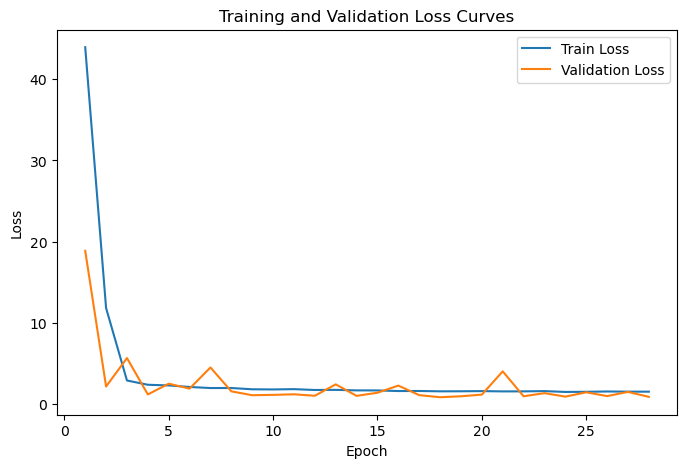

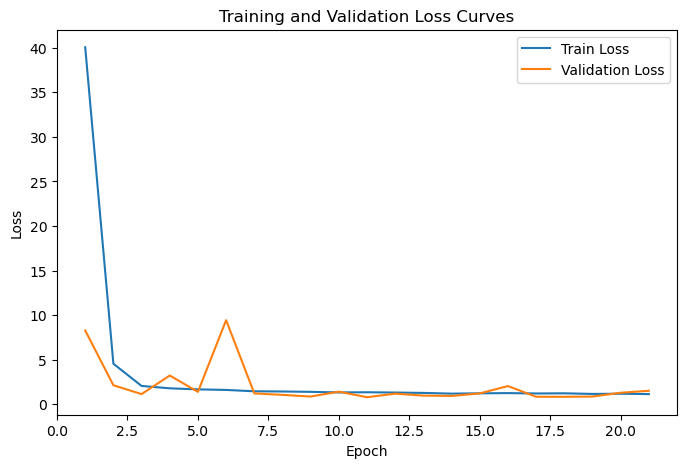

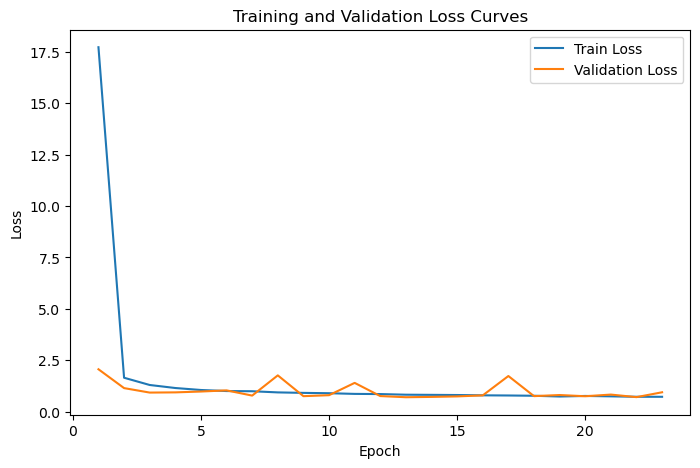

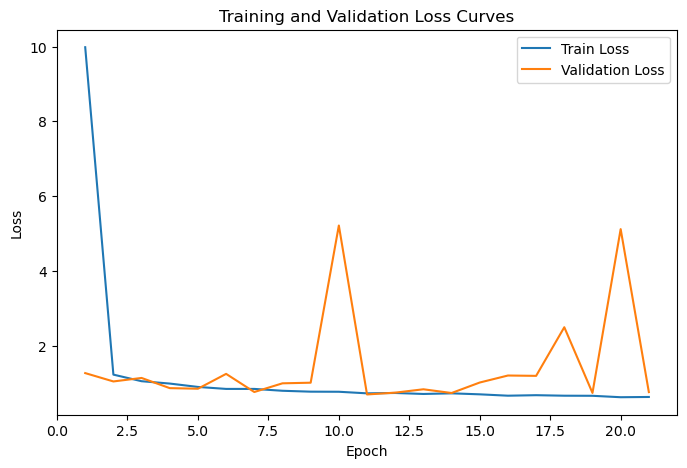

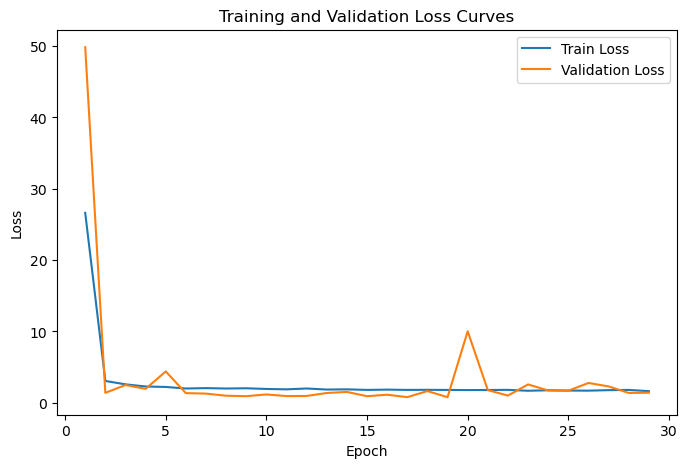

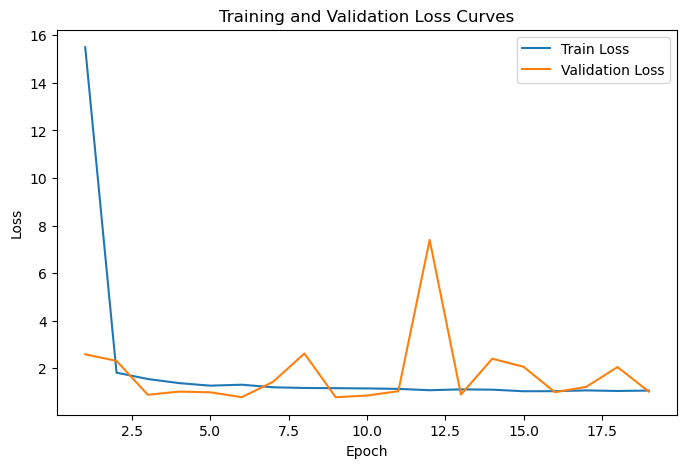

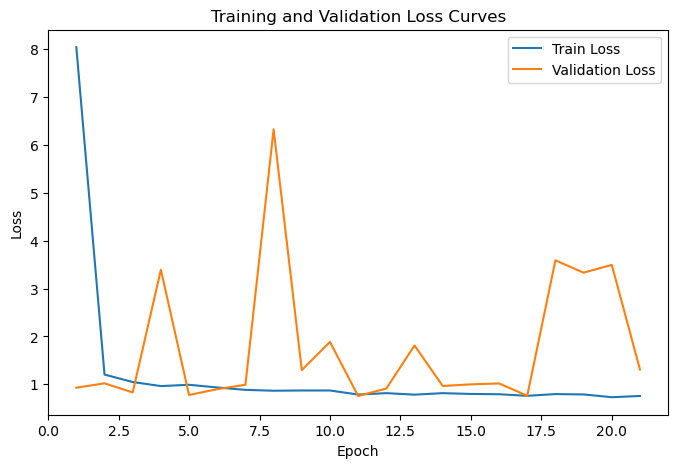

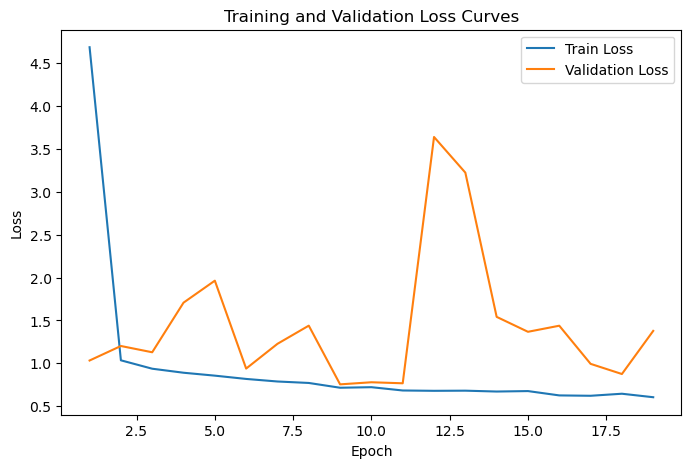

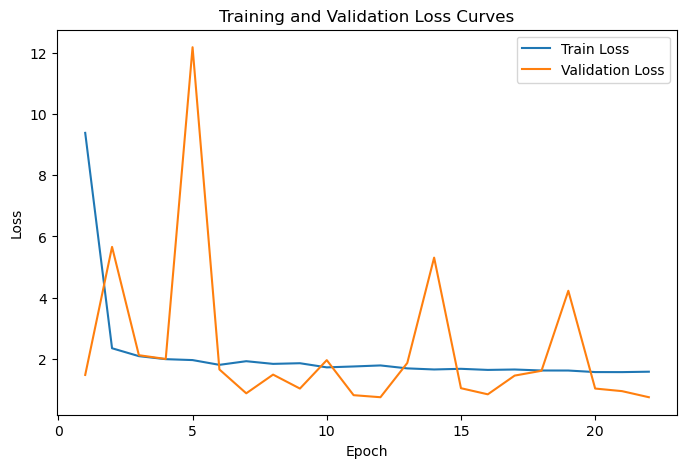

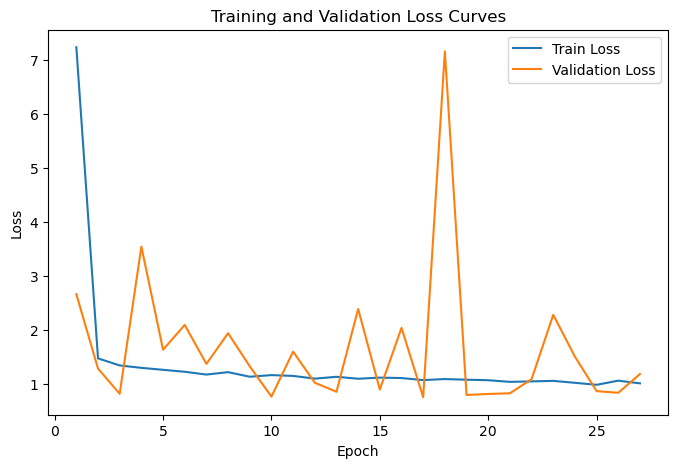

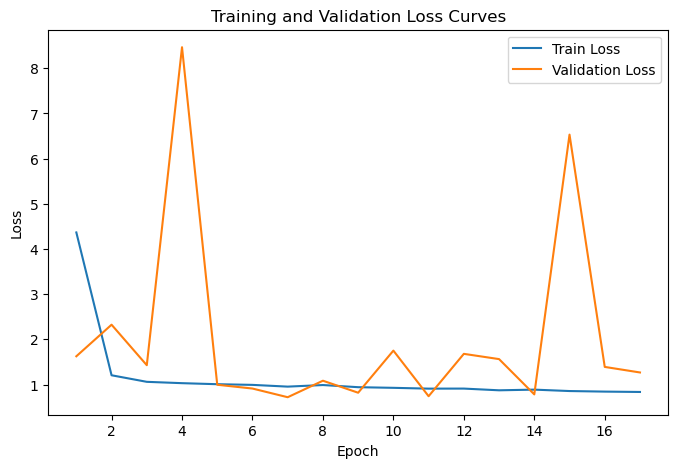

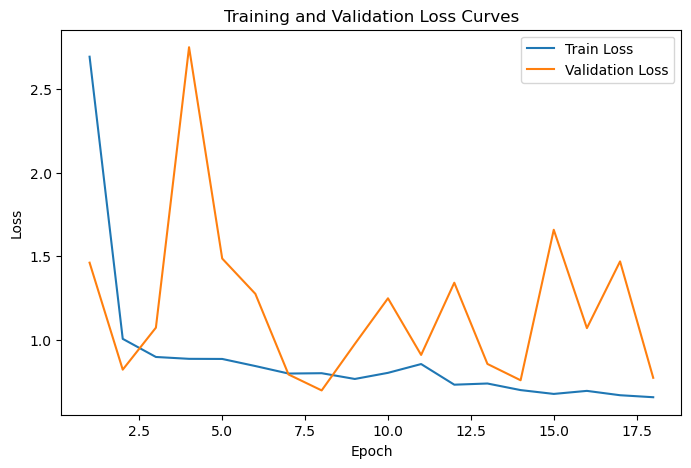

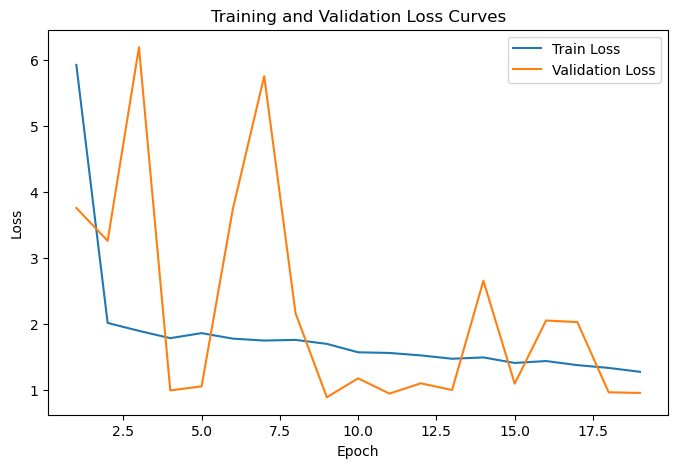

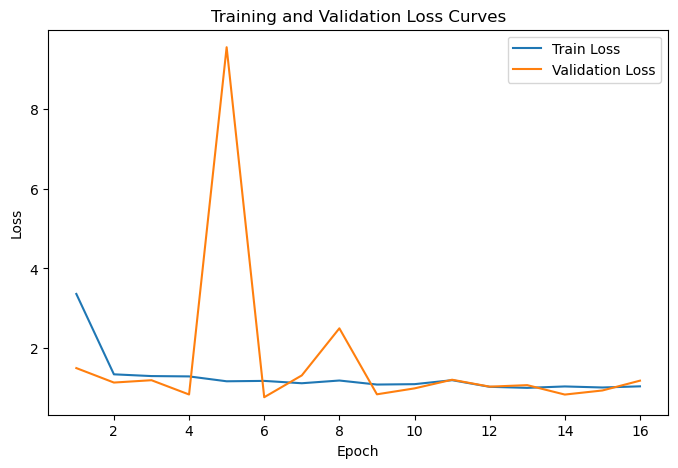

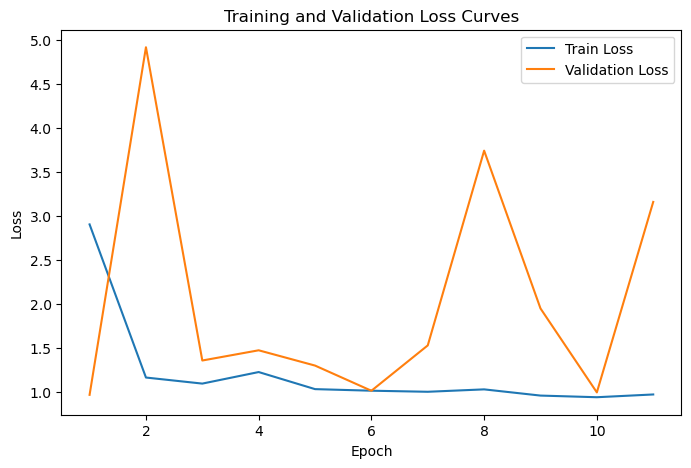

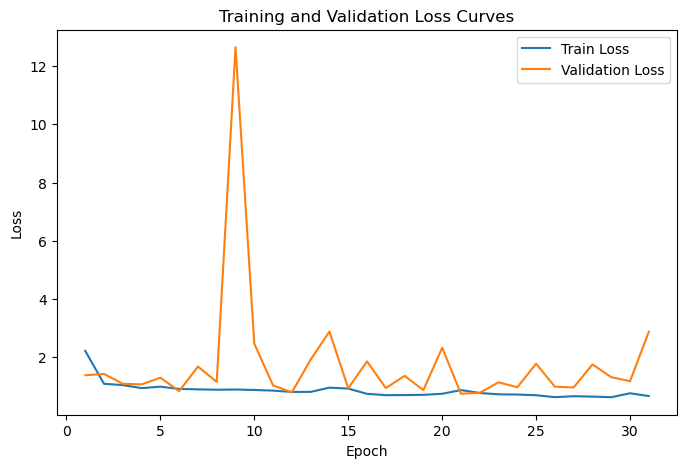

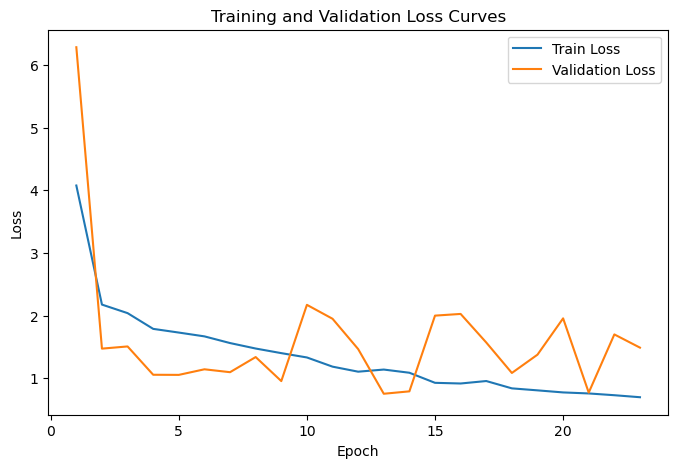

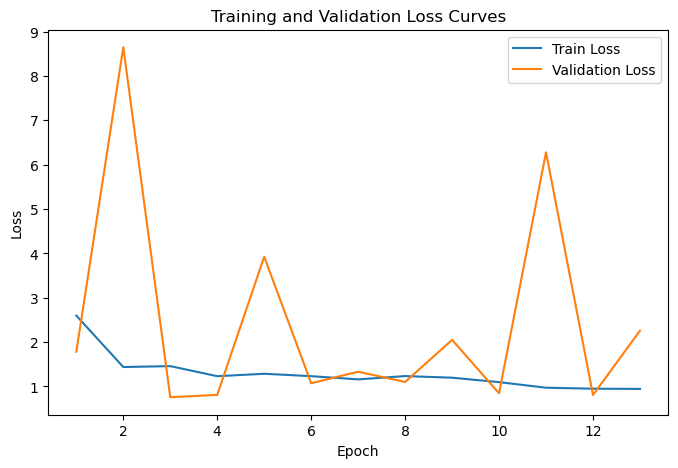

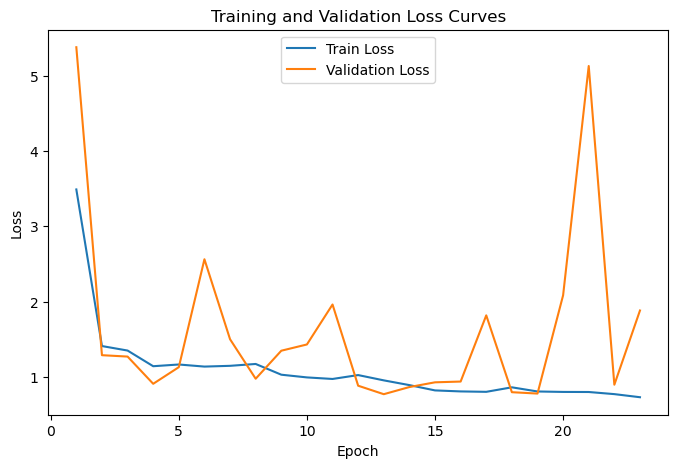

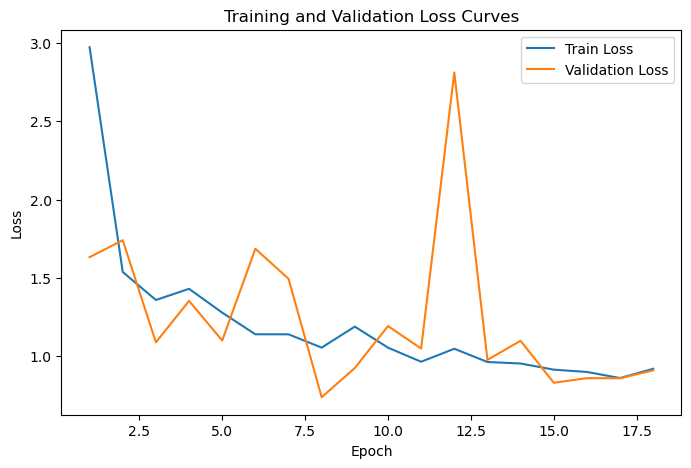

In [45]:
input_dim = data_list[0].x.shape[1]
sample_data = data_list[0]
global_feat_dim = sample_data.global_features.shape[0]
input_dim = sample_data.x.shape[1]

param_grid = {
    'lr': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],  # Learning rates spanning two orders of magnitude
    'hidden_dim': [32, 64, 128, 256],      # Network width
    # 'lr': [1e-4, 3e-4],  # Learning rates spanning two orders of magnitude
    # 'hidden_dim': [64, 128],      # Network width
    # 'num_layers': [2, 3, 5],               # GIN depth - common sweet spots
    # 'dropout': [0.0, 0.2, 0.5],            # Regularisation via dropout
    # 'batch_size': [32, 64, 128],           # Mini-batch sizes
    # 'weight_decay': [0.0, 1e-5, 1e-4],     # L2 regularisation on weights
    # 'readout': ['sum', 'mean', 'max'],     # Different aggregation schemes (depends on your GIN implementation)
    # 'activation': ['relu', 'leakyrelu'],   # Activation function choice
}

best_model = None
best_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"\nTraining with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss())

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

## Evaluation


Best params: {'lr': 0.001, 'hidden_dim': 256, 'input_dim': 40, 'global_feat_dim': 1038}

RMSE: 0.8350
MAE: 0.6569
R²: 0.6713


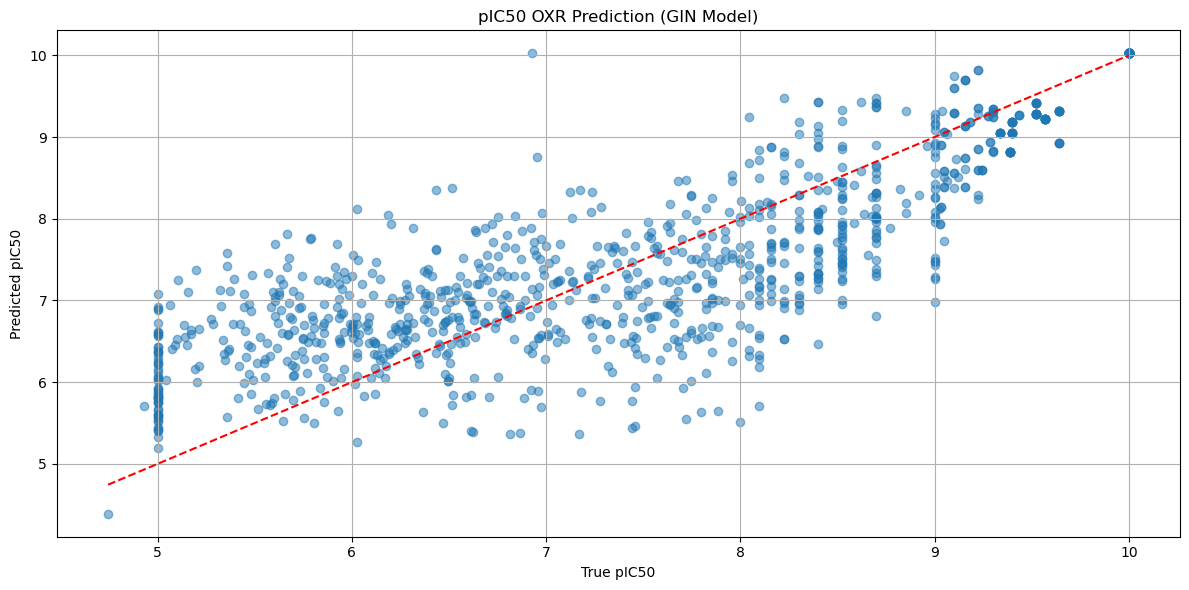

In [48]:
print(f"\nBest params: {best_params}")

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = best_model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("pIC50 OXR Prediction (GIN Model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("_images/true_vs_predicted_pic50s.png", dpi=300)
plt.show()

In [27]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import math
import os

output_dir = "_images"
os.makedirs(output_dir, exist_ok=True)

val_smiles = [d.smiles for d in val_list]

# Filter indices with error > 5 * true
outlier_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if abs(p - t) > 0.3 * abs(t)]
print(f"Number of outliers: {len(outlier_indices)}")

if len(outlier_indices) == 0:
    print("No outliers found. Skipping plot.")
else:
    mol_per_row = 5
    img_size = (300, 300)
    n_mols = len(outlier_indices)
    n_rows = math.ceil(n_mols / mol_per_row)

    fig, axs = plt.subplots(n_rows, mol_per_row, figsize=(mol_per_row * 3, n_rows * 3))
    axs = axs.flatten()

    for ax in axs:
        ax.axis('off')

    for i, idx in enumerate(outlier_indices):
        smiles = val_smiles[idx]
        true_val = y_true[idx]
        pred_val = y_pred[idx]
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            img = Draw.MolToImage(mol, size=img_size)
            axs[i].imshow(img)
            axs[i].set_title(f"T: {true_val:.2f}\nP: {pred_val:.2f}\nΔ: {abs(pred_val - true_val):.2f}", fontsize=8)
        else:
            axs[i].text(0.5, 0.5, "Invalid SMILES", ha='center', va='center')

    plt.tight_layout()
    grid_image_path = os.path.join(output_dir, "5x_outliers_grid.png")
    plt.savefig(grid_image_path, dpi=300)
    plt.close()
    print(f"Saved outlier grid image to: {grid_image_path}")



Number of outliers: 23
Saved outlier grid image to: _images/5x_outliers_grid.png


### Cross-validation run.

In [72]:
def train_fold(train_idx, val_idx, params):
    train_subset = [data_list[i] for i in train_idx]
    val_subset = [data_list[i] for i in val_idx]

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=custom_collate)

    def train_epoch_fold(model, loader, optimizer, loss_fn):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def eval_epoch_fold(model, loader, loss_fn):
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.to(device).float())
                total_loss += loss.item()
                all_preds.append(out.cpu())
                all_labels.append(batch.y.cpu())
        return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    for epoch in range(100):
        train_loss = train_epoch_fold(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch_fold(model, val_loader, loss_fn)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pth'))
    return model, val_loss

# Now run k-fold CV:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

# Best params: {'lr': 0.0001, 'hidden_dim': 128, 'input_dim': 40, 'global_feat_dim': 1038}

param_grid = {
    'lr': 0.0001,
    'hidden_dim': 128,
    'input_dim': 40,
    'global_feat_dim': 1038
}

val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(data_list)):
    print(f"\nFold {fold+1}")
    model, val_loss = train_fold(train_idx, val_idx, param_grid)
    val_losses.append(val_loss)

print(f"\nAverage validation loss across folds: {sum(val_losses)/len(val_losses):.4f}")


Fold 1
Epoch 1 | Train: 20.5897 | Val: 1.8584
Epoch 2 | Train: 1.5712 | Val: 1.0264
Epoch 3 | Train: 1.2678 | Val: 1.1708
Epoch 4 | Train: 1.1574 | Val: 0.8115
Epoch 5 | Train: 1.0934 | Val: 0.9702
Epoch 6 | Train: 1.0287 | Val: 1.7246
Epoch 7 | Train: 0.9749 | Val: 0.9833
Epoch 8 | Train: 0.9359 | Val: 0.7015
Epoch 9 | Train: 0.9229 | Val: 0.7081
Epoch 10 | Train: 0.9043 | Val: 0.7277
Epoch 11 | Train: 0.8637 | Val: 0.7095
Epoch 12 | Train: 0.9075 | Val: 1.6178
Epoch 13 | Train: 0.8866 | Val: 0.7610
Epoch 14 | Train: 0.8673 | Val: 0.7894
Epoch 15 | Train: 0.8143 | Val: 1.9478
Epoch 16 | Train: 0.8189 | Val: 0.8391
Epoch 17 | Train: 0.8035 | Val: 0.8389
Epoch 18 | Train: 0.8091 | Val: 0.9083
Early stopping triggered.

Fold 2
Epoch 1 | Train: 22.7275 | Val: 2.3918
Epoch 2 | Train: 1.5720 | Val: 1.0100
Epoch 3 | Train: 1.2895 | Val: 0.8738
Epoch 4 | Train: 1.1838 | Val: 0.8052
Epoch 5 | Train: 1.1187 | Val: 3.2978
Epoch 6 | Train: 1.0628 | Val: 0.7356
Epoch 7 | Train: 1.0064 | Val: 0.85

Final check; before saving, let's look at any significant differences in L2 weight norms between each model generated in CV.

In [ ]:
# Setup
FOLD_PATHS = [f'best_model_fold_{i}.pth' for i in range(5)]
DEVICE = 'cuda'  # or 'cuda' if available
sns.set(style='whitegrid')

# Need to redefine the model here
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool

class GINRegressor(nn.Module):
    def __init__(
        self,
        input_dim,              # atom feature dimension
        hidden_dim=128,         # width of graph layers
        global_feat_dim=0,      # dimension of global features (descriptors + fingerprints)
        global_hidden_dim=256,  # width of global feature encoder
        dropout=0.2
    ):
        super().__init__()

        # --- Graph (GNN) branch ---
        self.conv1 = GINConv(
            nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
        )
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = GINConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
        )
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # --- Global (descriptor/fingerprint) encoder ---
        if global_feat_dim > 0:
            self.global_encoder = nn.Sequential(
                nn.Linear(global_feat_dim, global_hidden_dim),
                nn.BatchNorm1d(global_hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(global_hidden_dim, hidden_dim),
                nn.ReLU(),
            )
        else:
            self.global_encoder = None

        # --- Fusion & prediction head ---
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2 if global_feat_dim > 0 else hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # --- Graph encoding ---
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h = h1 + h2  # residual connection
        g_emb = global_mean_pool(h, batch)  # [batch_size, hidden_dim]

        # --- Global feature encoding ---
        if hasattr(data, "global_features") and self.global_encoder is not None:
            gf = data.global_features.to(g_emb.device)
            if gf.ndim == 1:  # handle single-sample batch
                gf = gf.unsqueeze(0)
            gfeat_emb = self.global_encoder(gf)
            out = torch.cat([g_emb, gfeat_emb], dim=1)
        else:
            out = g_emb

        # --- Final prediction ---
        out = self.predictor(out)
        return out.squeeze(1)

# Use the best parameters from teh grid search in training
# Best params: {'lr': 0.0001, 'hidden_dim': 128, 'input_dim': 40, 'global_feat_dim': 1038}
params = {
    'input_dim': 40,         # Replace with your actual input_dim
    'hidden_dim': 128,        # Replace with your actual hidden_dim
    'global_feat_dim': 1038     # Replace if you used global features
}

# Load each model from disk
models = []
for fold_path in FOLD_PATHS:
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(DEVICE)
    state_dict = torch.load(fold_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    models.append(model)

# Extract all weights from each model
def get_all_weights(model: torch.nn.Module) -> np.ndarray:
    weights = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights.append(param.detach().cpu().numpy().flatten())
    return np.concatenate(weights)

def get_model():
    return GINRegressor(
        input_dim=40,
        hidden_dim=128,
        global_feat_dim=1038  # Optional
    )
    return model

# Load models and compute L2 norms per layer
def get_weight_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            norms[name] = param.data.norm(2).item()
    return norms

In [ ]:
# Histogram showing variance of aggregated weights 
# Collect weights and plot kdes
all_weights = {f'Fold {i}': get_all_weights(model) for i, model in enumerate(models)}

plt.figure(figsize=(12, 6))
for fold, weights in all_weights.items():
    sns.kdeplot(weights, label=fold, fill=True, alpha=0.3)
plt.title('Parameter Distribution Across Folds')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.savefig("_images/parameter_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

Seems all parameters vary tightly. How about a breakdown of each parameter across all folds?

In [ ]:
# Now let's have a look at each weight across all folds
# Collect norms for each model
norms_per_fold = {f'Fold {i}': get_weight_norms(model) for i, model in enumerate(models)}

df_norms = pd.DataFrame(norms_per_fold)

# Compute variance across folds per parameter
df_variance = df_norms.var(axis=1)

plt.figure(figsize=(12, 6))
sns.heatmap(df_variance.to_frame().T, cmap='Reds', cbar_kws={'label': 'Variance of L2 Norm'})
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.title('Variance of L2 Norms Per Layer Across Folds')
plt.tight_layout()
plt.savefig("_images/l2_norm_variance.png", dpi=300)
plt.show()

Some evidence of variance over all folds in a few metrics. Let's show a breakdown by fold to locate how many folds are affected and by how much.

In [ ]:
# Finally, let's look at the metrics per fold
num_folds = 5  
norms_per_fold = []

# TODO refactor so this isn't having to be loaded twice

for fold in range(num_folds):
    model = get_model()
    state_dict = torch.load(f'best_model_fold_{fold}.pth', map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    
    norms = get_weight_norms(model)
    norms_per_fold.append(norms)

df = pd.DataFrame(norms_per_fold)
df.index = [f'Fold {i}' for i in range(num_folds)]

plt.figure(figsize=(14, 6))
df.T.plot(kind='bar', figsize=(16, 6))
plt.title('L2 Norms of Model Weights Per Layer Across Folds')
plt.xlabel('Layer Name')
plt.ylabel('L2 Norm of Weights')
plt.grid(True)
plt.legend(title='Fold')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("_images/weight_norms_comparison.png", dpi=300)
plt.show()

# Transfer learning run

In [49]:
# Load chembl data

df_ep4 = pd.read_csv(f'P35408_bioactivity.csv',index_col=None)
df_ep4.head()

,molecule_chembl_id,target_chembl_id,target_pref_name,standard_type,standard_relation,standard_value,standard_units,assay_chembl_id,assay_type,assay_description,document_chembl_id,uniprot_id,target_pref_name.1,readout,doi,year,publication_date,smiles,pActivity
0,CHEMBL815,CHEMBL1836,Prostaglandin E2 receptor EP4 subtype,IC50,=,4200.00,nM,CHEMBL767812,B,Affinity for Prostanoid EP4 receptor expressed...,CHEMBL1132967,P35408,Prostaglandin E2 receptor EP4 subtype,IC50,10.1021/jm990542v,2000,2000-02-16,CCCCC[C@H](O)/C=C/[C@@H]1[C@@H](C/C=C\CCCC(=O)...,5.376751
1,CHEMBL815,CHEMBL1836,Prostaglandin E2 receptor EP4 subtype,IC50,=,4200.00,nM,CHEMBL767813,B,In vitro binding at EP4 human prostaglandin re...,CHEMBL1134785,P35408,Prostaglandin E2 receptor EP4 subtype,IC50,10.1021/jm010264b,2001,2001-10-02,CCCCC[C@H](O)/C=C/[C@@H]1[C@@H](C/C=C\CCCC(=O)...,5.376751
2,CHEMBL548,CHEMBL1836,Prostaglandin E2 receptor EP4 subtype,IC50,=,0.70,nM,CHEMBL765917,B,Inhibitory activity against human EP4 receptor...,CHEMBL1136653,P35408,Prostaglandin E2 receptor EP4 subtype,IC50,10.1016/s0960-894x(03)00042-8,2003,2003-03-01,CCCCC[C@H](O)/C=C/[C@H]1[C@H](O)CC(=O)[C@@H]1C...,9.154902
3,CHEMBL275667,CHEMBL1836,Prostaglandin E2 receptor EP4 subtype,IC50,=,1.40,nM,CHEMBL767814,B,Inhibitory activity against human EP4 receptor...,CHEMBL1136653,P35408,Prostaglandin E2 receptor EP4 subtype,IC50,10.1016/s0960-894x(03)00042-8,2003,2003-03-01,O=C1CC[C@H](/C=C/[C@@H](O)Cc2ccccc2)N1CCCCCCc1...,8.853872
4,CHEMBL231184,CHEMBL1836,Prostaglandin E2 receptor EP4 subtype,IC50,=,15848.93,nM,CHEMBL887240,B,Binding affinity to human EP4 receptor express...,CHEMBL1144577,P35408,Prostaglandin E2 receptor EP4 subtype,IC50,10.1016/j.bmcl.2006.11.059,2007,2007-02-01,Cc1ccc(-n2c(C)ccc2-c2cc(Cl)ccc2OCc2ccc(F)cc2)c...,4.800000


In [52]:
sampled_ep4 = hybrid_balanced_sampling(
    df_ep4,
    label_col='pActivity',
    split_threshold=5.0,
    n_bins_low=5,
    n_bins_high=5,
    target_size=500,
    random_state=42
)

/tmp/ipykernel_12084/1865856371.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)
/tmp/ipykernel_12084/1865856371.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)


In [53]:
s = sampled_ep4['pActivity']

counts, bins = np.histogram(s, bins=10)

# Print text histogram
for left, count in zip(bins[:-1], counts):
    bar = '█' * int(count / counts.max() * 50) 
    right = left + (bins[1] - bins[0])
    print(f"{left:6.2f} – {right:6.2f}: {bar} {count}")


  4.52 –   5.27: ████████████████████████████████ 22
  5.27 –   6.02: ███████████████████████████████████████ 27
  6.02 –   6.77: ██████████████████████████████████████ 26
  6.77 –   7.51: ████████████████████████████████████████████████ 33
  7.51 –   8.26: █████████████████████████████████ 23
  8.26 –   9.01: ████████████████████████████████████████████████ 33
  9.01 –   9.76: █████████████████████████████████████████████ 31
  9.76 –  10.50: ██████████████████████████████ 21
 10.50 –  11.25: ██████████████████████████████████████████████████ 34
 11.25 –  12.00: ███████████████████████ 16


In [57]:
# Convert SMILES + labels → PyG Data objects and attach SMILES as attribute
ep4_data_list = []
for smi, label in zip(sampled_ep4.smiles, sampled_ep4.pActivity):
    d = mol_to_graph(smi, label)
    if d is not None:
        d.smiles = smi  # attach SMILES string for later use
        ep4_data_list.append(d)


In [58]:
ep4_train, ep4_val = train_test_split(ep4_data_list, test_size=0.2, random_state=42)
ep4_train_loader = DataLoader(ep4_train, batch_size=16, shuffle=True, collate_fn=custom_collate)
ep4_val_loader   = DataLoader(ep4_val, batch_size=16, shuffle=False, collate_fn=custom_collate)

In [59]:
pretrained_model = GINRegressor(
    input_dim=input_dim,
    hidden_dim=best_params["hidden_dim"],
    global_feat_dim=best_params["global_feat_dim"],
    dropout=0.2
).to(device)

pretrained_model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [84]:
# --- 1. Start with only the predictor trainable ---
def freeze_all_except_predictor(model):
    for name, p in model.named_parameters():
        p.requires_grad = "predictor" in name

# --- 2. Unfreeze predictor + last GIN block ---
def unfreeze_last_gnn(model):
    for name, p in model.named_parameters():
        p.requires_grad = any(k in name for k in ["predictor", "conv2.nn", "bn2"])

# --- 3. Unfreeze all GNN layers (both conv1, conv2) ---
def unfreeze_all_gnn(model):
    for name, p in model.named_parameters():
        p.requires_grad = any(k in name for k in [
            "predictor", "conv1.nn", "bn1", "conv2.nn", "bn2"
        ])

# --- 4. Optional: finally unfreeze global encoder ---
def unfreeze_everything(model):
    for p in model.parameters():
        p.requires_grad = True


In [85]:
def make_optimizer(model, base_lr=1e-3):
    """Create optimizer with different LRs per group."""
    return torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters() if "predictor" in n and p.requires_grad], "lr": base_lr},
        {"params": [p for n, p in model.named_parameters() if "conv2" in n and p.requires_grad], "lr": base_lr * 0.5},
        {"params": [p for n, p in model.named_parameters() if "conv1" in n and p.requires_grad], "lr": base_lr * 0.25},
        {"params": [p for n, p in model.named_parameters() if "global_encoder" in n and p.requires_grad], "lr": base_lr * 0.25},
    ], weight_decay=1e-5)


In [86]:
freeze_all_except_predictor(pretrained_model)
optimizer = make_optimizer(pretrained_model, base_lr=1e-4)
loss_fn = torch.nn.MSELoss()

best_val_loss = float("inf")
patience, counter = 15, 0

# --- Training loop with staged unfreezing ---
for epoch in range(100):
    # Gradual unfreezing schedule
    if epoch == 0:
        freeze_all_except_predictor(pretrained_model)
    elif epoch == 10:
        print("\n[Stage 2] Unfreezing last GNN layer...")
        unfreeze_last_gnn(pretrained_model)
        optimizer = make_optimizer(pretrained_model, base_lr=1e-4)
    elif epoch == 20:
        print("\n[Stage 3] Unfreezing all GNN layers...")
        unfreeze_all_gnn(pretrained_model)
        optimizer = make_optimizer(pretrained_model, base_lr=1e-4)
    elif epoch == 40:
        print("\n[Stage 4] Unfreezing global encoder (full fine-tuning)...")
        unfreeze_everything(pretrained_model)
        optimizer = make_optimizer(pretrained_model, base_lr=5e-5)

    # Train & validate
    train_loss = train_epoch(pretrained_model, ep4_train_loader, optimizer, loss_fn)
    val_loss, preds, labels = eval_epoch(pretrained_model, ep4_val_loader, loss_fn)

    print(f"Epoch {epoch+1:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pretrained_model.state_dict(), "finetuned_ep4_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 2.0297 | Val: 1.9804
Epoch 002 | Train: 1.6586 | Val: 2.1533
Epoch 003 | Train: 1.7711 | Val: 2.3605
Epoch 004 | Train: 1.9414 | Val: 2.1988
Epoch 005 | Train: 1.7795 | Val: 2.3066
Epoch 006 | Train: 1.7983 | Val: 2.1629
Epoch 007 | Train: 1.9437 | Val: 2.3471
Epoch 008 | Train: 1.7217 | Val: 2.2332
Epoch 009 | Train: 1.7478 | Val: 2.1820
Epoch 010 | Train: 2.1660 | Val: 2.3386

[Stage 2] Unfreezing last GNN layer...
Epoch 011 | Train: 1.8834 | Val: 2.1570
Epoch 012 | Train: 1.8179 | Val: 2.2480
Epoch 013 | Train: 2.0235 | Val: 2.1580
Epoch 014 | Train: 1.6498 | Val: 2.0269
Epoch 015 | Train: 1.9943 | Val: 2.1826
Epoch 016 | Train: 1.7998 | Val: 2.2139
Early stopping triggered.


In [87]:
pretrained_model.load_state_dict(torch.load("finetuned_ep4_model.pth"))
val_loss, preds, labels = eval_epoch(pretrained_model, ep4_val_loader, loss_fn)

preds = preds.numpy()
labels = labels.numpy()

rmse = np.sqrt(np.mean((preds - labels)**2))
mae = np.mean(np.abs(preds - labels))
r2 = 1 - np.sum((preds - labels)**2) / np.sum((labels - np.mean(labels))**2)

print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


RMSE: 1.3641 | MAE: 1.1423 | R²: 0.5691


In [77]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "oxr_pic50_gin.pt")